# Predicting Diseases using Machine Learning

This notebook looks into using various Python-based machine learning and data science libraries in an attempt to build a machine learning model capable of predicting Stock Prices.

The following approaches will be taken:

Problem definition
Data
Evaluation
Features
Modelling
Experimentation

## 1. Problem Definition

> How well can I predict diseases given various patients' symptoms data and recommend various solutions such as workout, diet and medication?

## 2. Data

This version of data was found in:  https://www.kaggle.com/datasets/noorsaeed/medicine-recommendation-system-dataset

There are eight datasets:

* description.csv - Provides disease names with corresponding definitions and details.
* diets.csv - Contains diet recommendations for the diseases.
* precautions_df.csv - – Outlines precautionary measures for each disease. 
* medications.csv - Contains medicine prescribed for various diseases.
* symptom_sevirity.csv- Maps symptoms to its severity score (numerical scale).
* symptoms.csv - Contains various symptoms associated with the diseases.
* training.csv - Training dataset mapping symptoms to diseases for ML model training.
* workout.csv - Suggests lifestyle changes and dietary adjustments.

## 3. Evaluation

The evaluation metrics for this project are: Accuracy, Precision, Recall, F1 score and Confusion matrix.

## 4. Features

The dataset contains several features across different files:

**training.csv**

This is the main dataset for ML model training. It includes:

Symptom1, Symptom2, Symptom3, … → Columns representing patient-reported symptoms.

Disease → Target label mapping symptoms to a specific disease.


**symptom_severity.csv**

Symptom → Name of the symptom.

Weight → Numerical score representing the severity of the symptom.


**description.csv**

Disease → Name of the disease.

Description → Textual details about the disease.


**medications.csv**

Disease → Disease name.

Medication → Recommended medicine.


**diets.csv**

Disease → Disease name.

Diet → Food/diet recommendations.


**workout.csv**

Disease → Disease name.

Workout → Suggested workouts and lifestyle adjustments.


**precautions_df.csv**

Disease → Disease name.

Precaution_1, Precaution_2, Precaution_3, Precaution_4 → Recommended precautions.



**symptoms.csv**

Symptom → Symptom name.

Disease → Associated disease.


## Preparing the tools

In [35]:
import os
import warnings
warnings.filterwarnings('ignore')

# Regular EDA (exploratory data analysis) and plotting libraries
%matplotlib inline
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Models
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier

# Model Evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix

## Load Data

In [2]:
training_df = pd.read_csv("Data/Training.csv")
diet_df = pd.read_csv("Data/diets.csv")
medications_df = pd.read_csv("Data/medications.csv")
description_df = pd.read_csv("Data/description.csv")
precautions_df = pd.read_csv("Data/precautions_df.csv", index_col=[0])
symptoms_df = pd.read_csv("Data/symtoms_df.csv", index_col=[0])
symptoms_severity_df = pd.read_csv("Data/Symptom-severity.csv")
workout_df = pd.read_csv("Data/workout_df.csv", index_col=[0, 1])



## Exploratory Data Analysis (EDA)

In [3]:
training_df.head()

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection


In [4]:
medications_df.head()

,Disease,Medication
0,Fungal infection,"['Antifungal Cream', 'Fluconazole', 'Terbinafi..."
1,Allergy,"['Antihistamines', 'Decongestants', 'Epinephri..."
2,GERD,"['Proton Pump Inhibitors (PPIs)', 'H2 Blockers..."
3,Chronic cholestasis,"['Ursodeoxycholic acid', 'Cholestyramine', 'Me..."
4,Drug Reaction,"['Antihistamines', 'Epinephrine', 'Corticoster..."


In [5]:
diet_df.head()

,Disease,Diet
0,Fungal infection,"['Antifungal Diet', 'Probiotics', 'Garlic', 'C..."
1,Allergy,"['Elimination Diet', 'Omega-3-rich foods', 'Vi..."
2,GERD,"['Low-Acid Diet', 'Fiber-rich foods', 'Ginger'..."
3,Chronic cholestasis,"['Low-Fat Diet', 'High-Fiber Diet', 'Lean prot..."
4,Drug Reaction,"['Antihistamine Diet', 'Omega-3-rich foods', '..."


In [6]:
description_df.head()

,Disease,Description
0,Fungal infection,Fungal infection is a common skin condition ca...
1,Allergy,Allergy is an immune system reaction to a subs...
2,GERD,GERD (Gastroesophageal Reflux Disease) is a di...
3,Chronic cholestasis,Chronic cholestasis is a condition where bile ...
4,Drug Reaction,Drug Reaction occurs when the body reacts adve...


In [7]:
symptoms_df.head()

,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4
0,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches
1,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN
2,Fungal infection,itching,nodal_skin_eruptions,dischromic _patches,NaN
3,Fungal infection,itching,skin_rash,dischromic _patches,NaN
4,Fungal infection,itching,skin_rash,nodal_skin_eruptions,NaN


In [8]:
symptoms_severity_df.head()

,Symptom,weight
0,itching,1
1,skin_rash,3
2,nodal_skin_eruptions,4
3,continuous_sneezing,4
4,shivering,5


In [9]:
precautions_df.head()

,Disease,Precaution_1,Precaution_2,Precaution_3,Precaution_4
0,Drug Reaction,stop irritation,consult nearest hospital,stop taking drug,follow up
1,Malaria,Consult nearest hospital,avoid oily food,avoid non veg food,keep mosquitos out
2,Allergy,apply calamine,cover area with bandage,NaN,use ice to compress itching
3,Hypothyroidism,reduce stress,exercise,eat healthy,get proper sleep
4,Psoriasis,wash hands with warm soapy water,stop bleeding using pressure,consult doctor,salt baths


In [10]:
workout_df.head()

,,disease,workout
,Unnamed: 0,,
0,0,Fungal infection,Avoid sugary foods
1,1,Fungal infection,Consume probiotics
2,2,Fungal infection,Increase intake of garlic
3,3,Fungal infection,Include yogurt in diet
4,4,Fungal infection,Limit processed foods


In [11]:
workout_df = workout_df.reset_index(drop=True)

In [12]:
workout_df.head()

,disease,workout
0,Fungal infection,Avoid sugary foods
1,Fungal infection,Consume probiotics
2,Fungal infection,Increase intake of garlic
3,Fungal infection,Include yogurt in diet
4,Fungal infection,Limit processed foods


In [13]:
training_df.describe()

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,pus_filled_pimples,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze
count,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,...,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000
mean,0.137805,0.159756,0.021951,0.045122,0.021951,0.162195,0.139024,0.045122,0.045122,0.021951,...,0.021951,0.021951,0.021951,0.023171,0.023171,0.023171,0.023171,0.023171,0.023171,0.023171
std,0.344730,0.366417,0.146539,0.207593,0.146539,0.368667,0.346007,0.207593,0.207593,0.146539,...,0.146539,0.146539,0.146539,0.150461,0.150461,0.150461,0.150461,0.150461,0.150461,0.150461
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [14]:
training_df.info(max_cols=134)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4920 entries, 0 to 4919
Data columns (total 133 columns):
 #    Column                          Non-Null Count  Dtype 
---   ------                          --------------  ----- 
 0    itching                         4920 non-null   int64 
 1    skin_rash                       4920 non-null   int64 
 2    nodal_skin_eruptions            4920 non-null   int64 
 3    continuous_sneezing             4920 non-null   int64 
 4    shivering                       4920 non-null   int64 
 5    chills                          4920 non-null   int64 
 6    joint_pain                      4920 non-null   int64 
 7    stomach_pain                    4920 non-null   int64 
 8    acidity                         4920 non-null   int64 
 9    ulcers_on_tongue                4920 non-null   int64 
 10   muscle_wasting                  4920 non-null   int64 
 11   vomiting                        4920 non-null   int64 
 12   burning_micturition             

In [15]:
training_df.isna().sum()

itching                 0
skin_rash               0
nodal_skin_eruptions    0
continuous_sneezing     0
shivering               0
                       ..
inflammatory_nails      0
blister                 0
red_sore_around_nose    0
yellow_crust_ooze       0
prognosis               0
Length: 133, dtype: int64

There are no missing values in our training data

### Number of Symptoms per Disease

In [16]:
symptoms_df = training_df.copy()

symptoms_col = [col for col in symptoms_df.columns if col != 'prognosis']

symptoms_df['symptom_count'] = symptoms_df[symptoms_col].sum(axis=1)

symptoms_per_disease = symptoms_df.groupby('prognosis')['symptom_count'].sum()

symptoms_per_disease

prognosis
(vertigo) Paroymsal  Positional Vertigo     678
AIDS                                        438
Acne                                        438
Alcoholic hepatitis                         798
Allergy                                     432
Arthritis                                   570
Bronchial Asthma                            672
Cervical spondylosis                        558
Chicken pox                                1266
Chronic cholestasis                         798
Common Cold                                1992
Dengue                                     1626
Diabetes                                   1152
Dimorphic hemmorhoids(piles)                570
Drug Reaction                               546
Fungal infection                            432
GERD                                        666
Gastroenteritis                             438
Heart attack                                438
Hepatitis B                                1392
Hepatitis C                   

### Distribution of Diseases

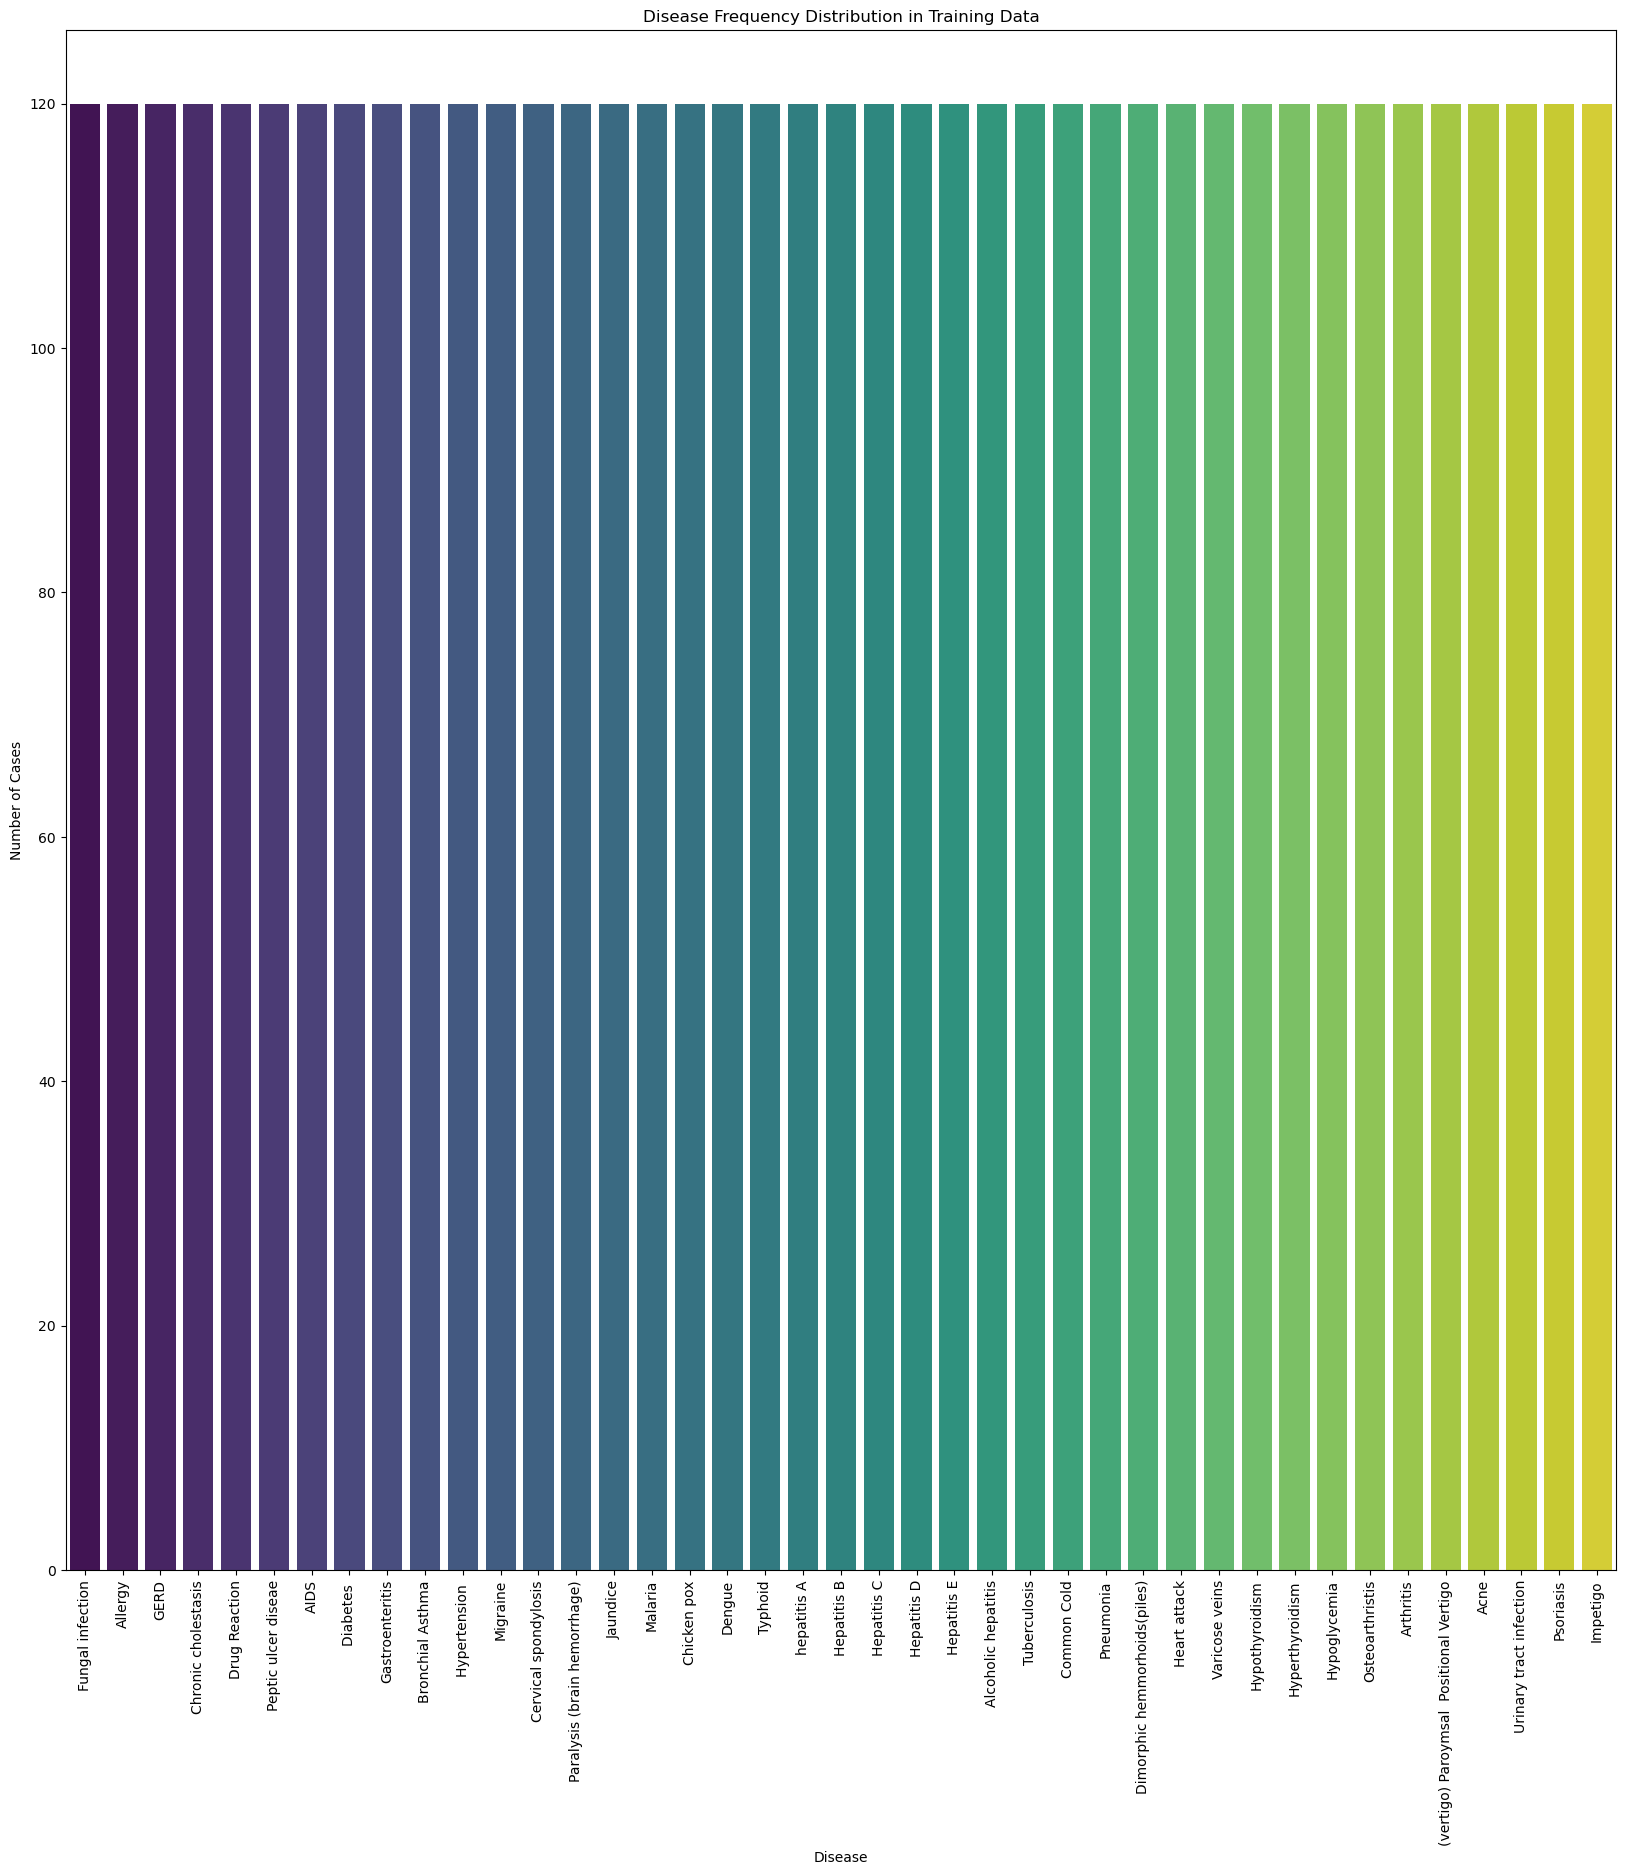

In [17]:
disease_count = training_df['prognosis'].value_counts()

plt.figure(figsize=(20,20))
sns.barplot(x=disease_count.index, y=disease_count.values, palette="viridis")

plt.xticks(rotation=90)
plt.xlabel("Disease")
plt.ylabel("Number of Cases")
plt.title("Disease Frequency Distribution in Training Data")

plt.show()

Data is evenly distributed.

### Distribution of Symptoms Severity

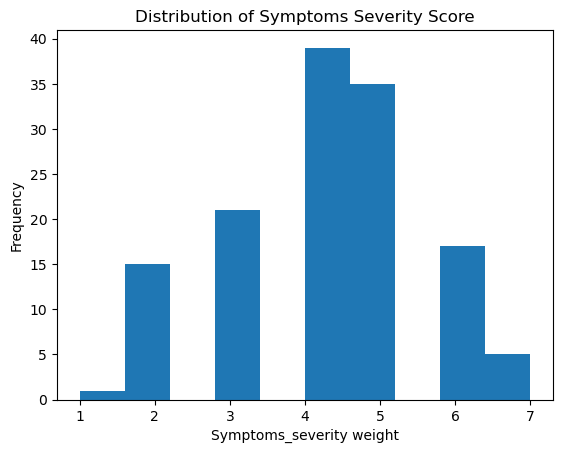

In [18]:
plt.hist(symptoms_severity_df['weight'])

plt.xlabel('Symptoms_severity weight')
plt.ylabel('Frequency')
plt.title('Distribution of Symptoms Severity Score')

plt.show()

### Average severity score across all symptoms

In [19]:
avg_score = symptoms_severity_df.groupby('Symptom')['weight'].mean()

avg_score

Symptom
abdominal_pain           4.0
abnormal_menstruation    6.0
acidity                  3.0
acute_liver_failure      6.0
altered_sensorium        2.0
                        ... 
weight_loss              3.0
yellow_crust_ooze        3.0
yellow_urine             4.0
yellowing_of_eyes        4.0
yellowish_skin           3.0
Name: weight, Length: 132, dtype: float64

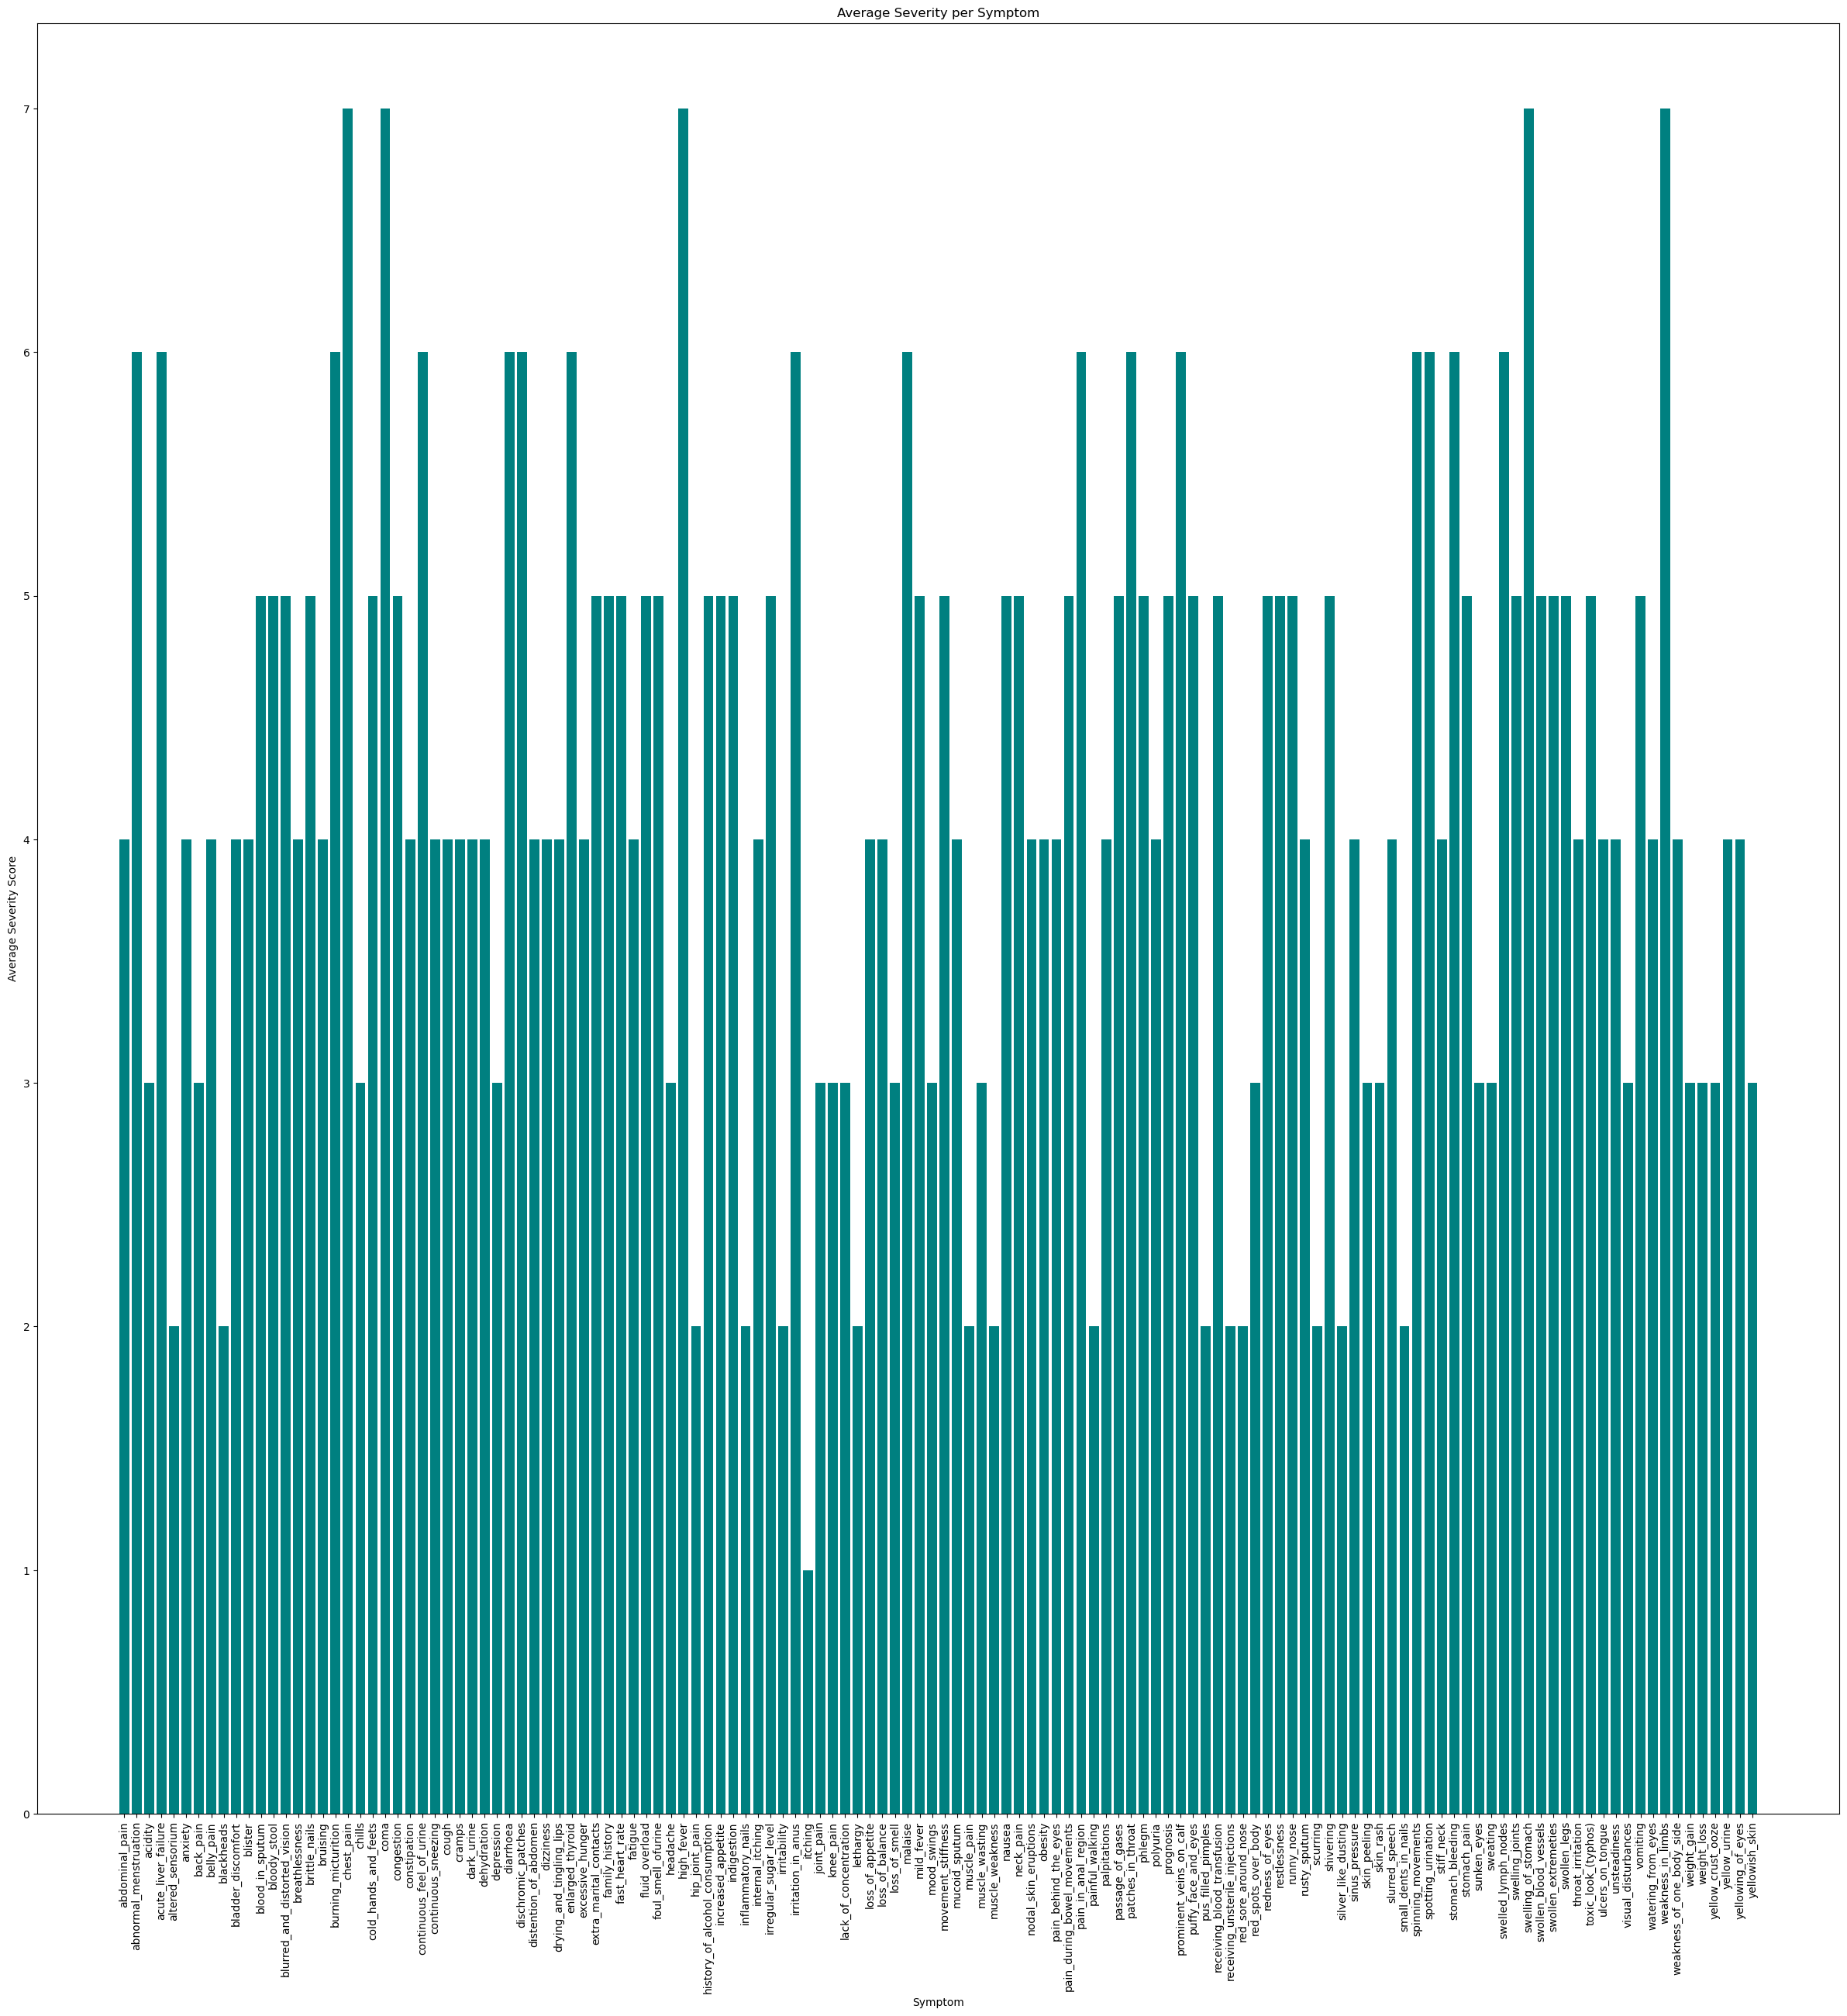

In [20]:
plt.figure(figsize=(30, 30))

plt.bar(avg_score.index, avg_score.values, color='Teal')

plt.xticks(rotation=90)
plt.xlabel("Symptom")
plt.ylabel("Average Severity Score")
plt.title("Average Severity per Symptom")

plt.show()

## 5. Modelling

In [21]:
X = training_df.drop('prognosis',  axis=1)

y = training_df['prognosis']

le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
models = {"RandomForest":RandomForestClassifier(random_state=42),
          "KNB":KNeighborsClassifier(),
          "LinearRegression":LogisticRegression(random_state=42),
          "XGB":XGBClassifier(random_state=42)}

def fit_and_score(models, X_train, X_test, y_train, y_test):
    """
    Fits and evaluate given machine learning models.
    models : a dict of different Scikit-Learn machine learning models
    X_train : training data (no labels)
    X_test : testing data (no labels)
    y_train : training labels
    y_test: test labels
    """
    model_scores = {}

    for name,  model in models.items():
        model.fit(X_train, y_train)
        model_scores[name] = model.score(X_test, y_test)

    return model_scores

In [23]:
model_scores = fit_and_score(models = models,
                             X_train = X_train, 
                             X_test = X_test, 
                             y_train = y_train, 
                             y_test = y_test)

model_scores

{'RandomForest': 1.0, 'KNB': 1.0, 'LinearRegression': 1.0, 'XGB': 1.0}

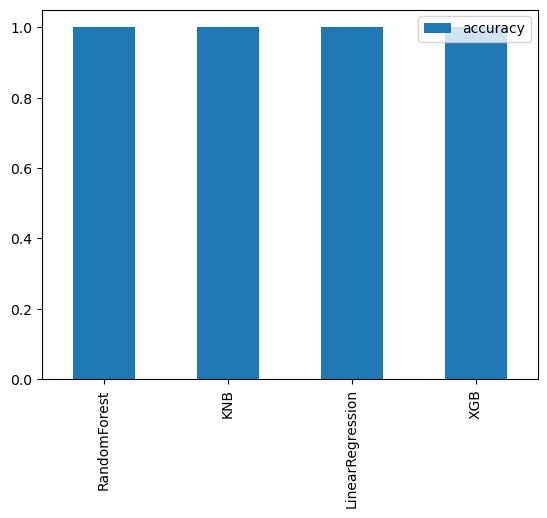

In [24]:
model_compare = pd.DataFrame(model_scores, index=["accuracy"])
model_compare.T.plot.bar()
plt.show()

## 6. Evaluation

1.  Accuracy, Precision, Recall, F1 score

In [25]:
model_preds = {}

print("\nModel Performance Metrics:")
for model_name, model in models.items():
    y_preds = model.predict(X_test)  
    model_preds[model_name] = y_preds 

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_preds) * 100
    precision = precision_score(y_test, y_preds, average='weighted')
    recall = recall_score(y_test, y_preds, average='weighted')
    f1 = f1_score(y_test, y_preds, average='weighted')

    # Print results in the required format
    print(f"\n{model_name} Model:")
    print(f"Accuracy: {accuracy:.2f}%")
    print(f"Precision: {precision:.2f}")
    print(f"Recall: {recall:.2f}")
    print(f"F1 Score: {f1:.2f}") 


Model Performance Metrics:

RandomForest Model:
Accuracy: 100.00%
Precision: 1.00
Recall: 1.00
F1 Score: 1.00

KNB Model:
Accuracy: 100.00%
Precision: 1.00
Recall: 1.00
F1 Score: 1.00

LinearRegression Model:
Accuracy: 100.00%
Precision: 1.00
Recall: 1.00
F1 Score: 1.00

XGB Model:
Accuracy: 100.00%
Precision: 1.00
Recall: 1.00
F1 Score: 1.00


2. Confusion Matrix


 Confusion Matrices:
Confusion Matrix Plot for RandomForest:



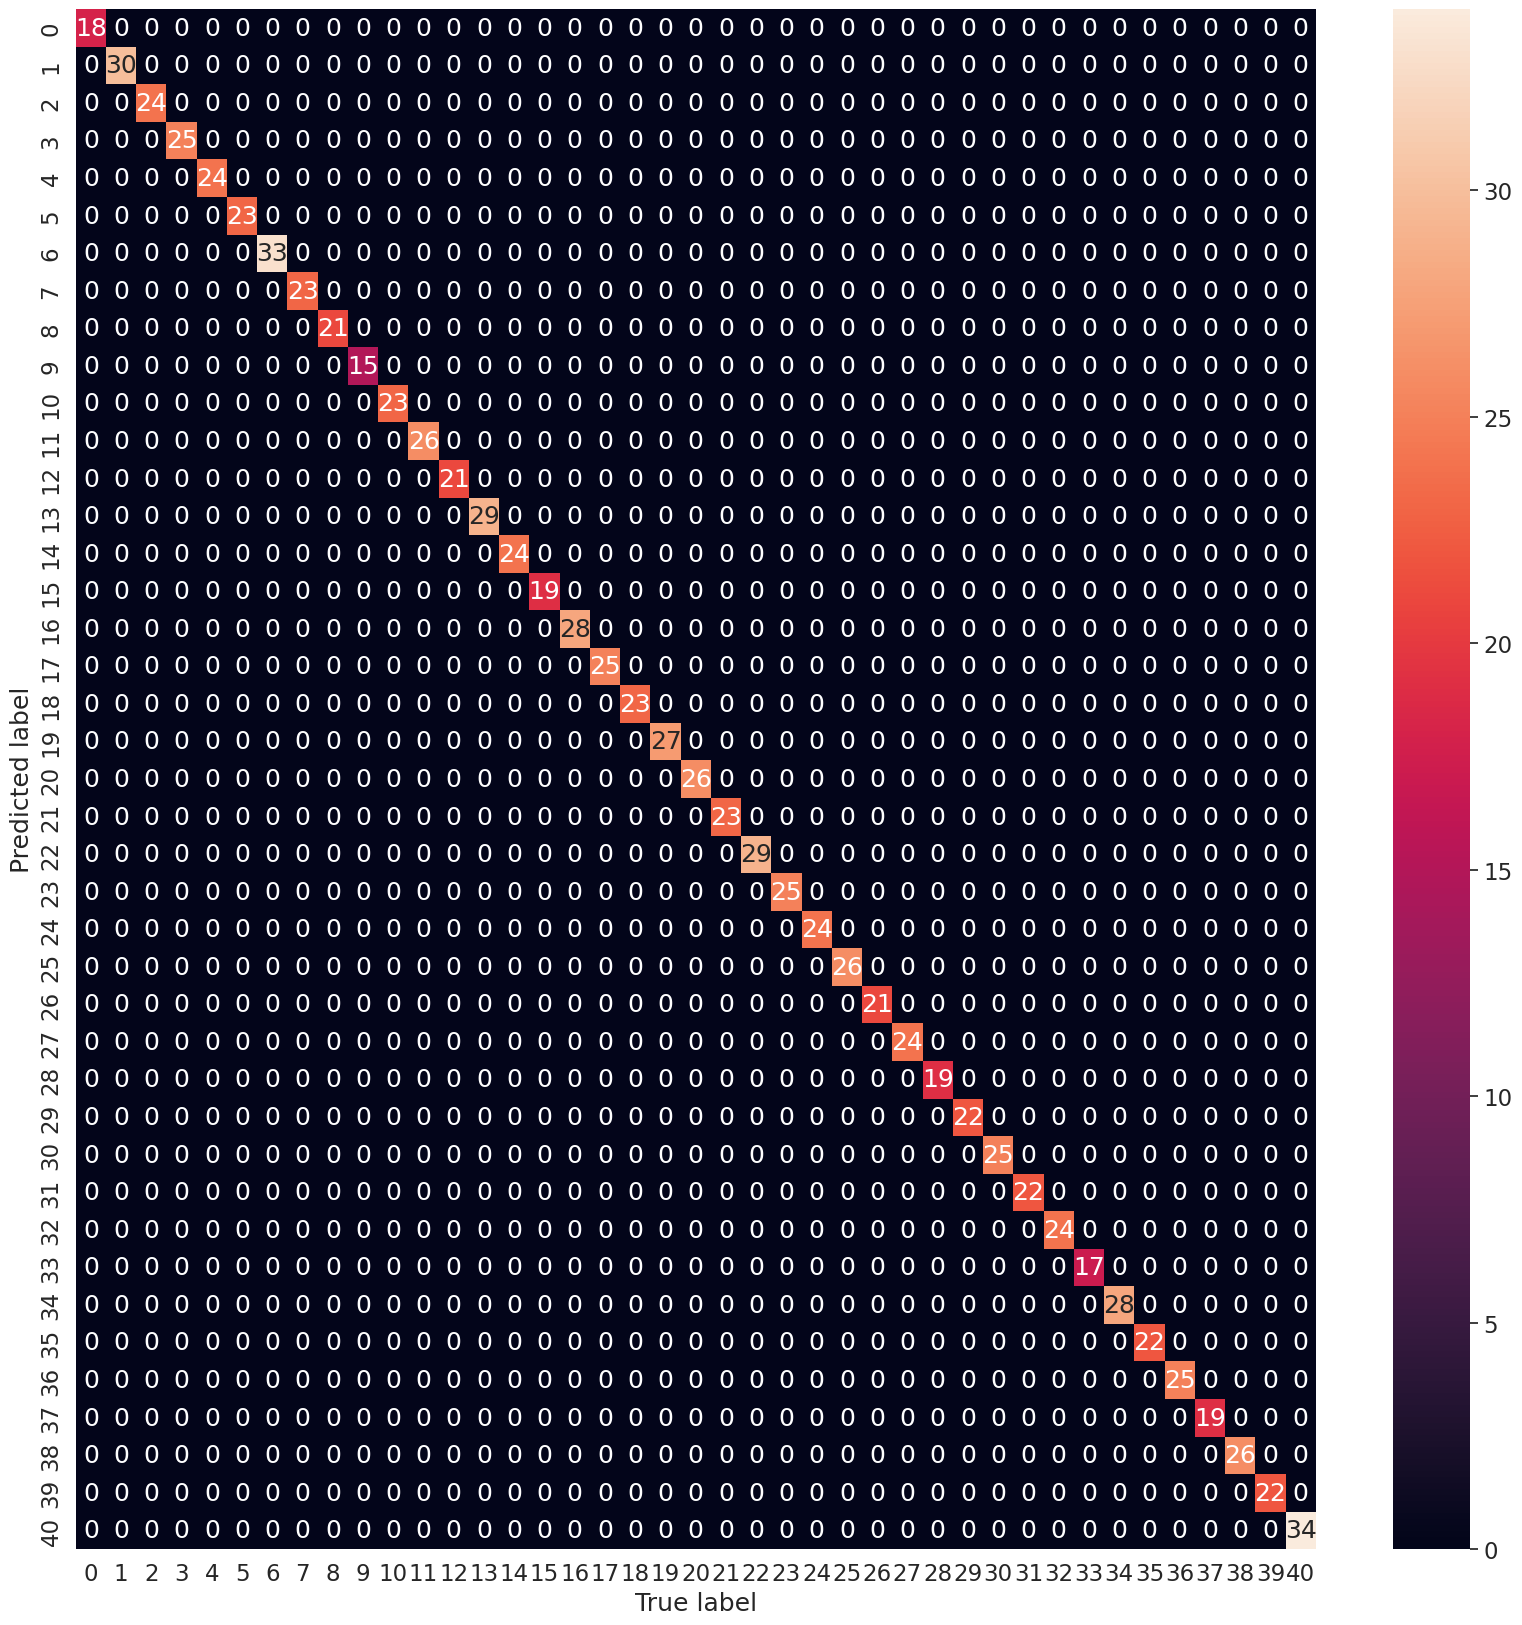

Confusion Matrix Plot for KNB:



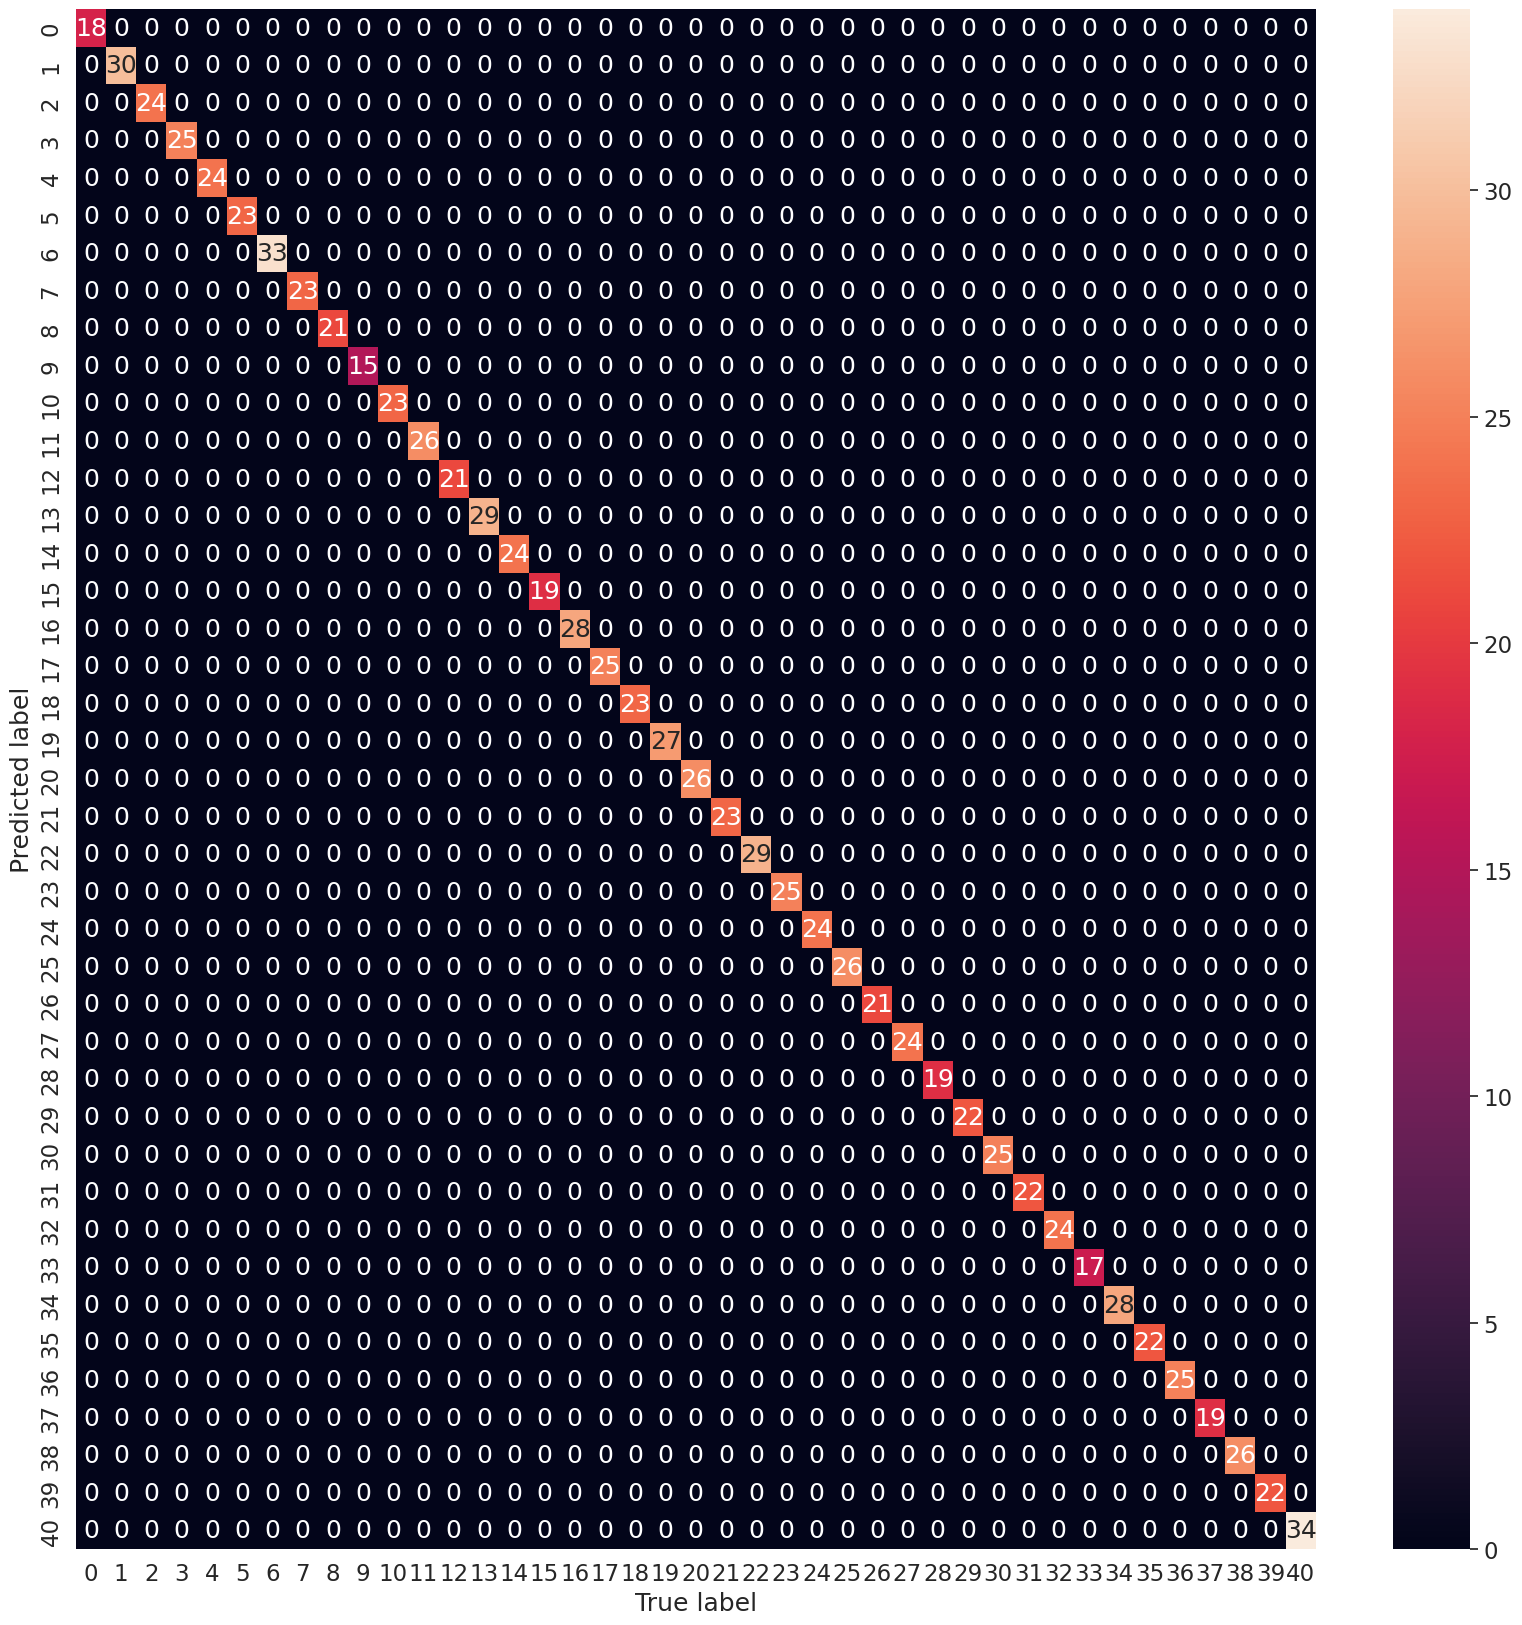

Confusion Matrix Plot for LinearRegression:



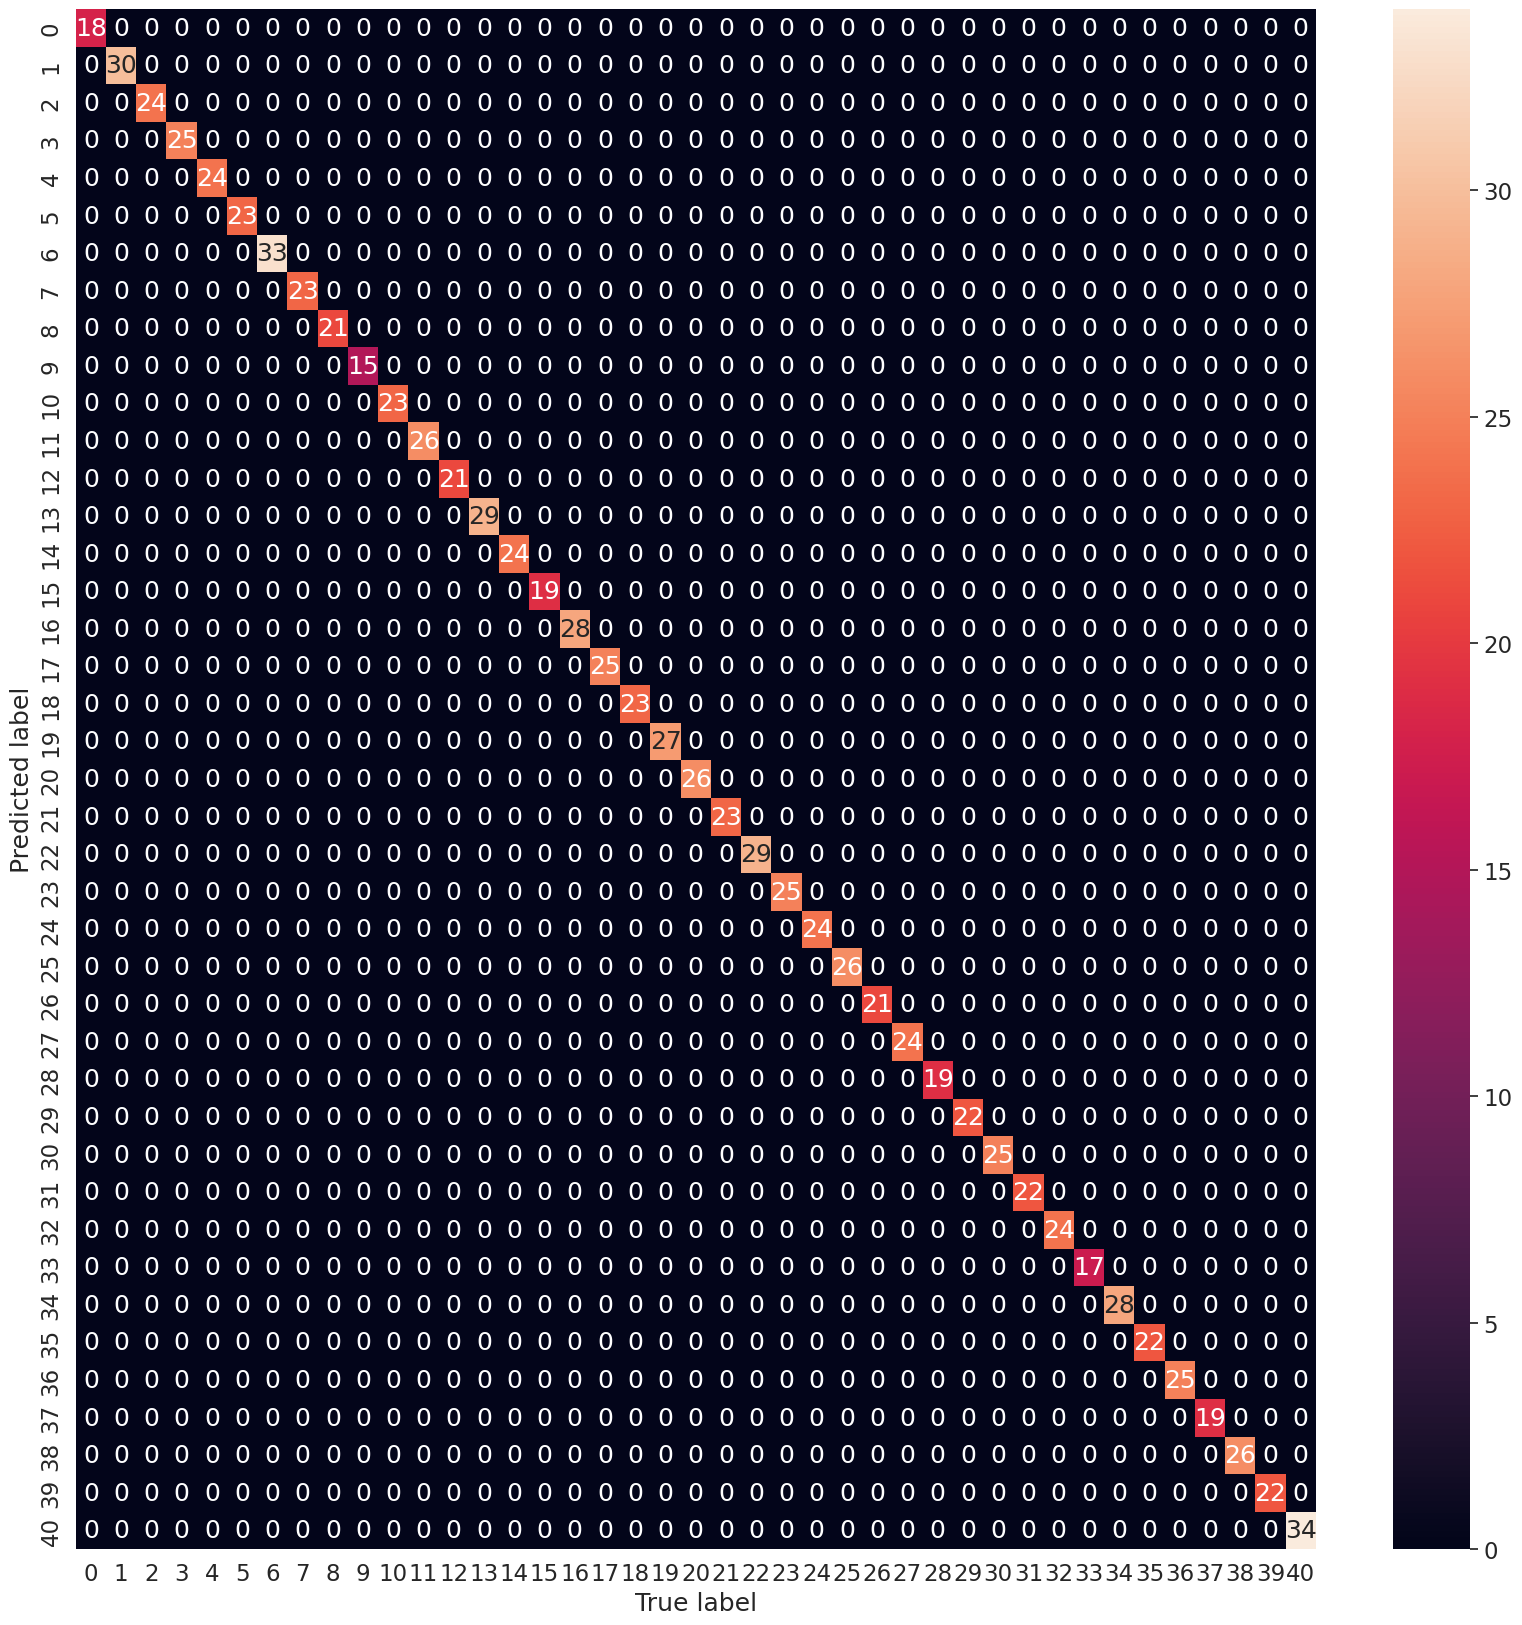

Confusion Matrix Plot for XGB:



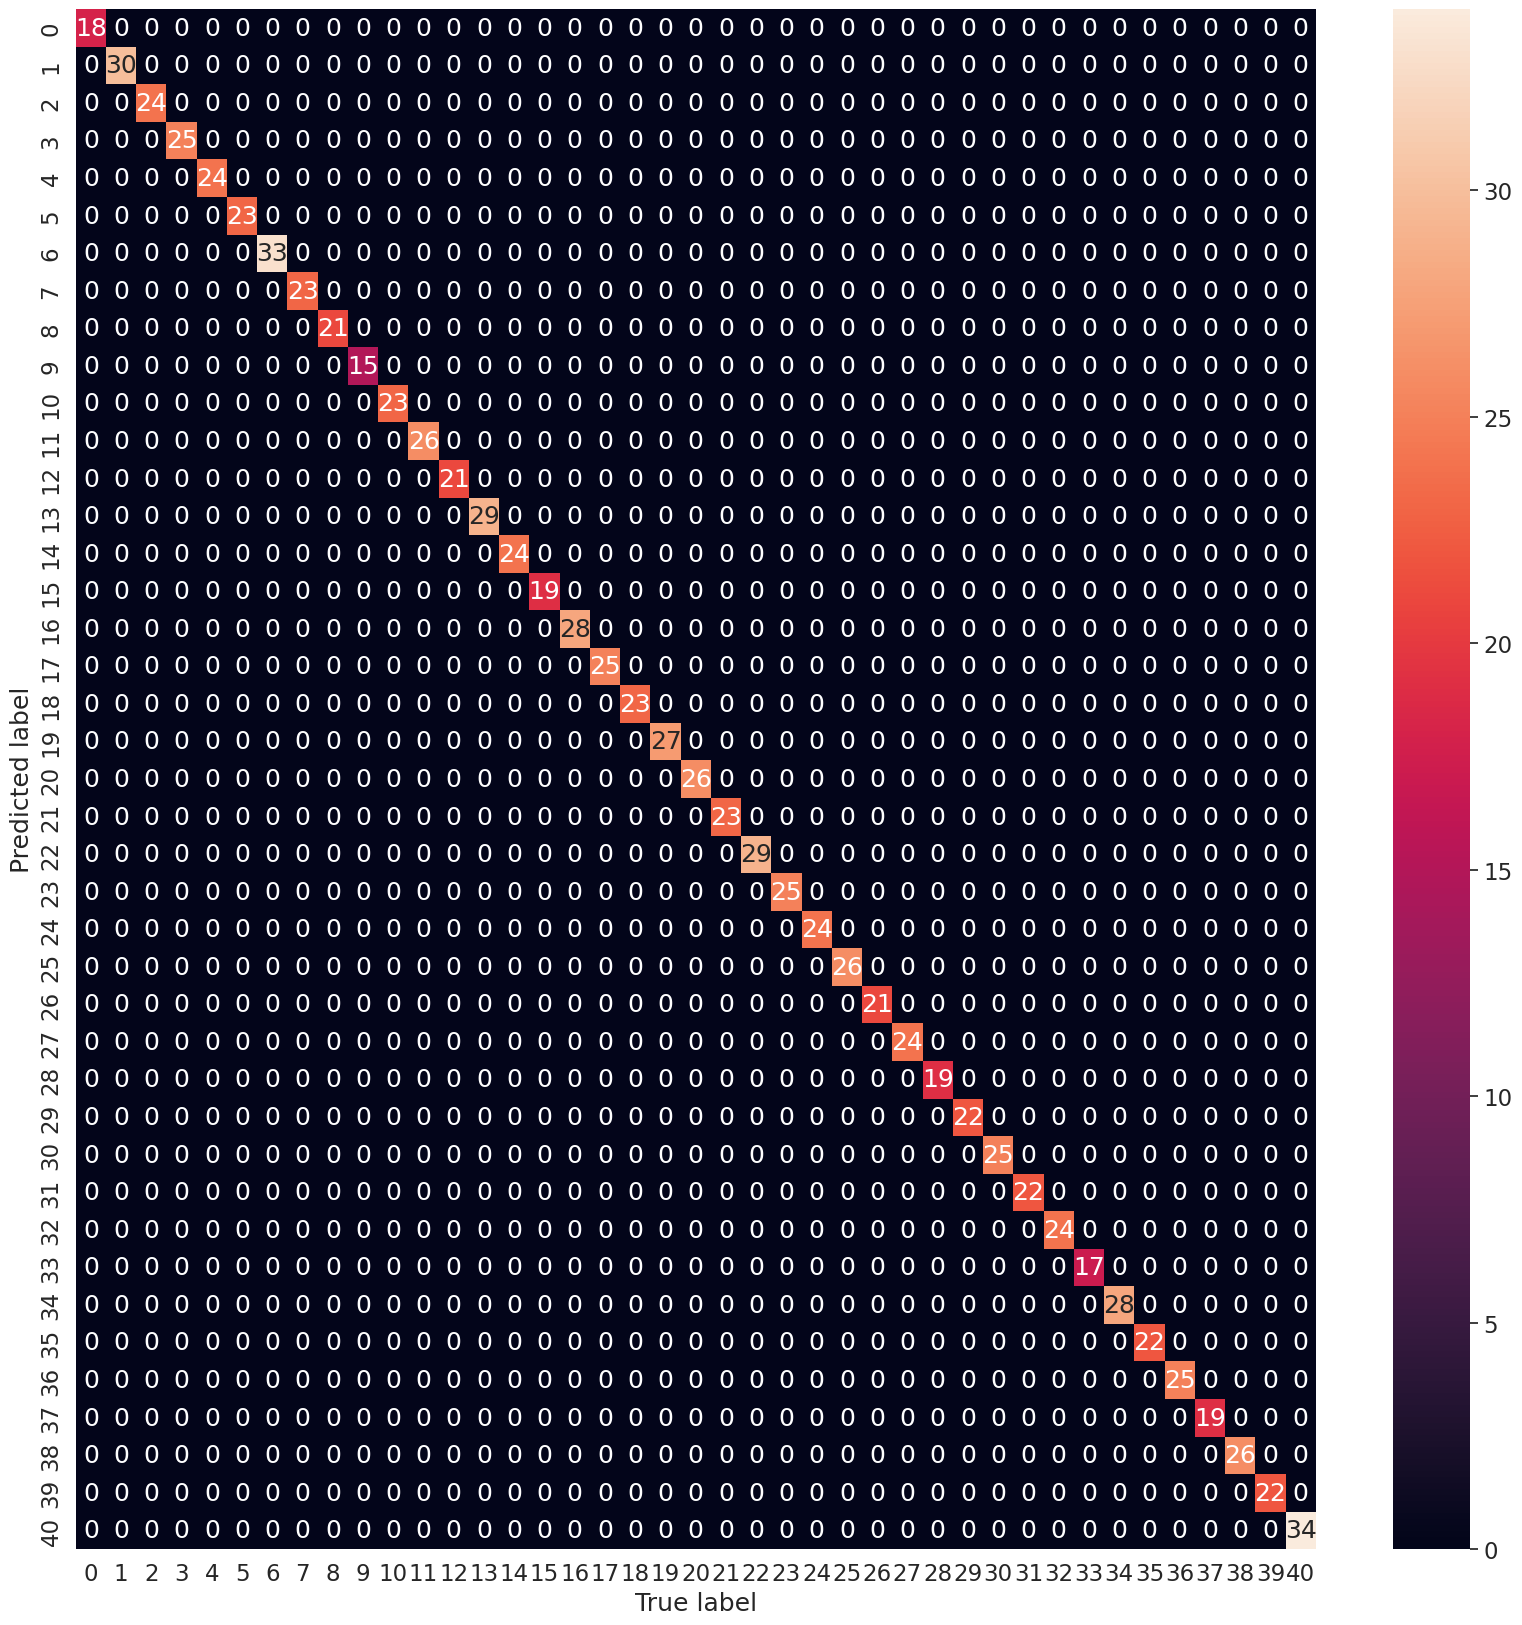

In [30]:
confusion_matrices = {}

print("\n Confusion Matrices:")
for model_name, model in models.items():
    sns.set(font_scale=1.5)
    print(f"Confusion Matrix Plot for {model_name}:\n")
    fig, ax = plt.subplots(figsize=(20, 20))
    ax = sns.heatmap(confusion_matrix(y_test, y_preds),
                     annot=True,
                     cbar=True)
    plt.xlabel("True label")
    plt.ylabel("Predicted label")
    plt.show()


#### Picking a single model for Prediction

In [36]:
random_forest = models["RandomForest"]

### Saving the Model

In [37]:
from joblib import dump, load

dump(random_forest, filename="Models/Random-Forest-Model.joblib")

['Models/Random-Forest-Model.joblib']

In [39]:
my_model = load("Models/Random-Forest-Model.joblib")

In [52]:
print(f"Original Test Data: \n" , y_test)
print("" * 100)
print("=" * 100)
print("" * 100)
print(f"Model Prediction Data: \n" , my_model.predict(X_test))

Original Test Data: 
 [ 2  2 24  1  9 23 25  5 19 30 38 12 21 35  3  3 13 22 12  7  6 40 19  6
  4 20 34 30 26 30  9 19 17 22 39 30 28 14 34 38 20  0 23 12 28 17 25 19
 35 35 18 36 39  4 24 20 37 10 38 33 25 24 36 18  0 26 32  1  0 13 15  6
  2 22 26  9 27 27 10 30 16 27 16 14 19  1 28 17  0 11 26 29 21  3 36 17
 29 18 34 11 23  6  3  4 33 39 16 30 22  1 21 39 18 25 12 14 26 28 25  3
  7 35 32  8  5 34 17 24 35 31 11  7  7  7  9  2 19 34 13 37 33 18 35 19
 21 31 14 39 36  3 12 31 33 37 23 37 25 21  3  4  6 28  1 18 40 37 29  6
 27 24 40 21 40 17 34 27  1 40 10  8 29  1  4 40 30 37 12 19 11 38 37  2
 39 34 22  8 15  7 19 31 17 40 39 11 15  0 16  4  9  8 19 31 18 13 17 28
 29 18  9 21 11  3  3 23 32 40  8 17 26 35  5 13 37 34 35 14 31  6 12  5
 10 20  4 39 32 36 36  9 32 18 19 22 13 11 27 34 13 10 10  1 18 10 10 14
  0 26 10  8 13 25 26  5 29 37 26 16 30 27 34  1 37 24 40 35 24 33  6 36
 12 33 16 11 22 40 15 11 19 14  1 15 36  6 27 22 35 19 23 31 16 32 20 15
 33  1 25  7  6 20 13 15 40 2

In [56]:
unique_values = []
unique_values2 = []

disease_dict = {}

for item in y:
    if item not in unique_values:
        unique_values.append(item)
    
for i in training_df["prognosis"].unique() :
    if i not in unique_values2:
        unique_values2.append(i)

for i in range (0 , len(unique_values2)) :
    disease_dict.update({unique_values[i] : unique_values2[i]})

print(disease_dict)

{15: 'Fungal infection', 4: 'Allergy', 16: 'GERD', 9: 'Chronic cholestasis', 14: 'Drug Reaction', 33: 'Peptic ulcer diseae', 1: 'AIDS', 12: 'Diabetes ', 17: 'Gastroenteritis', 6: 'Bronchial Asthma', 23: 'Hypertension ', 30: 'Migraine', 7: 'Cervical spondylosis', 32: 'Paralysis (brain hemorrhage)', 28: 'Jaundice', 29: 'Malaria', 8: 'Chicken pox', 11: 'Dengue', 37: 'Typhoid', 40: 'hepatitis A', 19: 'Hepatitis B', 20: 'Hepatitis C', 21: 'Hepatitis D', 22: 'Hepatitis E', 3: 'Alcoholic hepatitis', 36: 'Tuberculosis', 10: 'Common Cold', 34: 'Pneumonia', 13: 'Dimorphic hemmorhoids(piles)', 18: 'Heart attack', 39: 'Varicose veins', 26: 'Hypothyroidism', 24: 'Hyperthyroidism', 25: 'Hypoglycemia', 31: 'Osteoarthristis', 5: 'Arthritis', 0: '(vertigo) Paroymsal  Positional Vertigo', 2: 'Acne', 38: 'Urinary tract infection', 35: 'Psoriasis', 27: 'Impetigo'}


In [59]:
unique_values3 = []
unique_values4 = []

symptoms_dict = {}

for item in training_df.columns:
    if item not in unique_values3:
        if item != "prognosis":
            unique_values3.append(item)

for i in range (0 , len(training_df.columns)) :
    if i not in unique_values4:
        unique_values4.append(i)
 
for i in range(len(training_df.columns)-1) :
    symptoms_dict.update({unique_values3[i] : unique_values4[i]})

print(symptoms_dict)

{'itching': 0, 'skin_rash': 1, 'nodal_skin_eruptions': 2, 'continuous_sneezing': 3, 'shivering': 4, 'chills': 5, 'joint_pain': 6, 'stomach_pain': 7, 'acidity': 8, 'ulcers_on_tongue': 9, 'muscle_wasting': 10, 'vomiting': 11, 'burning_micturition': 12, 'spotting_ urination': 13, 'fatigue': 14, 'weight_gain': 15, 'anxiety': 16, 'cold_hands_and_feets': 17, 'mood_swings': 18, 'weight_loss': 19, 'restlessness': 20, 'lethargy': 21, 'patches_in_throat': 22, 'irregular_sugar_level': 23, 'cough': 24, 'high_fever': 25, 'sunken_eyes': 26, 'breathlessness': 27, 'sweating': 28, 'dehydration': 29, 'indigestion': 30, 'headache': 31, 'yellowish_skin': 32, 'dark_urine': 33, 'nausea': 34, 'loss_of_appetite': 35, 'pain_behind_the_eyes': 36, 'back_pain': 37, 'constipation': 38, 'abdominal_pain': 39, 'diarrhoea': 40, 'mild_fever': 41, 'yellow_urine': 42, 'yellowing_of_eyes': 43, 'acute_liver_failure': 44, 'fluid_overload': 45, 'swelling_of_stomach': 46, 'swelled_lymph_nodes': 47, 'malaise': 48, 'blurred_and

In [60]:
def get_prediction(symptoms) :
    input_vector = np.zeros(len(symptoms_dict))
    
    for item in symptoms:
        input_vector[symptoms_dict[item]] = 1
    
    return disease_dict[my_model.predict([input_vector])[0]]

In [87]:
symptoms = input("Key in your symptoms")



Key in your symptoms itching, scurring, skin_peeling, muscle_weakness, swollen_legs, chest_pain


In [88]:
symptoms = symptoms.lower()

patient_symptoms = [s.strip() for s in symptoms.split(',')]

patient_symptoms = [sym.strip() for sym in patient_symptoms]

In [89]:
predicted_disease = get_prediction(patient_symptoms)

print("predicted_disease: " , predicted_disease)

predicted_disease:  Acne
